<a href="https://colab.research.google.com/github/Anastasia-Pom/Machine-learning-2026/blob/main/%D0%9B%D0%A09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Лабораторная работа №9**

Тема: Методы обучения без учителя.
Цель: изучение методов кластеризации и снижения размерности.

Решается задача обучения без учителя: выполняется снижение размерности данных методами PCA и t-SNE, а также кластеризация методами KMeans, Agglomerative Clustering и DBSCAN.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

plt.rcParams['figure.figsize'] = (8, 6)

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving synthetic_coffee_health_10000.csv to synthetic_coffee_health_10000.csv


In [ ]:
df = pd.read_csv('synthetic_coffee_health_10000.csv')
print(df.head)

<bound method NDFrame.head of          ID  Age  Gender  Country  Coffee_Intake  Caffeine_mg  Sleep_Hours  \
0         1   40    Male  Germany            3.5        328.1          7.5   
1         2   33    Male  Germany            1.0         94.1          6.2   
2         3   42    Male   Brazil            5.3        503.7          5.9   
3         4   53    Male  Germany            2.6        249.2          7.3   
4         5   32  Female    Spain            3.1        298.0          5.3   
...     ...  ...     ...      ...            ...          ...          ...   
9995   9996   50  Female    Japan            2.1        199.8          6.0   
9996   9997   18  Female       UK            3.4        319.2          5.8   
9997   9998   26    Male    China            1.6        153.4          7.1   
9998   9999   40  Female  Finland            3.4        327.1          7.0   
9999  10000   42  Female   Brazil            2.9        277.5          6.4   

     Sleep_Quality   BMI  Heart_R

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
drive_file_path = "/content/drive/MyDrive/synthetic_coffee_health_10000.csv"
df = pd.read_csv("/content/drive/MyDrive/synthetic_coffee_health_10000.csv")

df.head()

Mounted at /content/drive


,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption
0,1,40,Male,Germany,3.5,328.1,7.5,Good,24.9,78,Low,14.5,No,Other,0,0
1,2,33,Male,Germany,1.0,94.1,6.2,Good,20.0,67,Low,11.0,No,Service,0,0
2,3,42,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Mild,Office,0,0
3,4,53,Male,Germany,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Mild,Other,0,0
4,5,32,Female,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Mild,Student,0,1


In [ ]:
features = [
    'ID',
    'Age',
    'Gender',
    'Country',
    'Coffee_Intake',
    'Caffeine_mg',
    'Sleep_Hours',
    'Sleep_Quality',
    'BMI',
    'Heart_Rate',
    'Stress_Level',
    'Physical_Activity_Hours',
    'Health_Issues',
    'Occupation',
    'Smoking',
    'Alcohol_Consumption'
    ]

D1_raw = df[features].copy()

print("Размер исходного D1:", D1_raw.shape)
print(D1_raw.head())

Размер исходного D1: (10000, 16)
   ID  Age  Gender  Country  Coffee_Intake  Caffeine_mg  Sleep_Hours  \
0   1   40    Male  Germany            3.5        328.1          7.5   
1   2   33    Male  Germany            1.0         94.1          6.2   
2   3   42    Male   Brazil            5.3        503.7          5.9   
3   4   53    Male  Germany            2.6        249.2          7.3   
4   5   32  Female    Spain            3.1        298.0          5.3   

  Sleep_Quality   BMI  Heart_Rate Stress_Level  Physical_Activity_Hours  \
0          Good  24.9          78          Low                     14.5   
1          Good  20.0          67          Low                     11.0   
2          Fair  22.7          59       Medium                     11.2   
3          Good  24.7          71          Low                      6.6   
4          Fair  24.1          76       Medium                      8.5   

  Health_Issues Occupation  Smoking  Alcohol_Consumption  
0            No      Oth

In [ ]:
numeric_features = [
    'Age',
    'Coffee_Intake',
    'Caffeine_mg',
    'Sleep_Hours',
    'BMI',
    'Heart_Rate',
    'Physical_Activity_Hours',
]

categorical_features = [
    'Gender',
    'Country',
    'Sleep_Quality',
    'Stress_Level',
    'Health_Issues',
    'Occupation',
    'Smoking',
    'Alcohol_Consumption'
]

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

try:
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
except TypeError:
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse=False))
    ])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

D1 = preprocessor.fit_transform(D1_raw)

print("Размер D1 после предобработки:", D1.shape)

Размер D1 после предобработки: (10000, 50)


In [ ]:
pca = PCA(n_components=2, random_state=42)
D2 = pca.fit_transform(D1)

D2_df = pd.DataFrame(D2, columns=['PC1', 'PC2'])

print("Размер D2:", D2_df.shape)
print("Доля объяснённой дисперсии:", pca.explained_variance_ratio_)
print(D2_df.head())

Размер D2: (10000, 2)
Доля объяснённой дисперсии: [0.18872606 0.12467657]
        PC1       PC2
0  0.405291  1.277932
1 -1.395399 -0.375362
2  2.972967 -0.048870
3 -0.068145  0.097573
4  1.432272 -1.288430


In [ ]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=42
)

D3 = tsne.fit_transform(D1)

D3_df = pd.DataFrame(D3, columns=['TSNE1', 'TSNE2'])

print("Размер D3:", D3_df.shape)
print(D3_df.head())

Размер D3: (10000, 2)
       TSNE1      TSNE2
0  -1.981195 -17.197699
1   7.055356  33.979679
2  16.729385 -77.452454
3 -39.214375 -19.731890
4  -5.532810 -79.344032


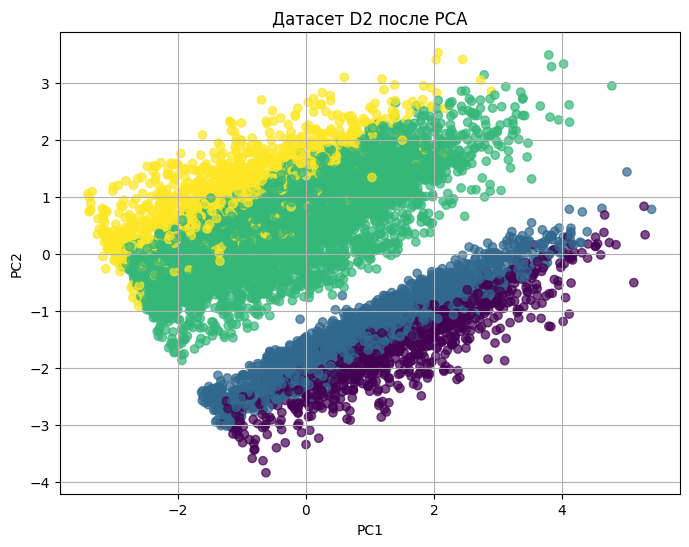

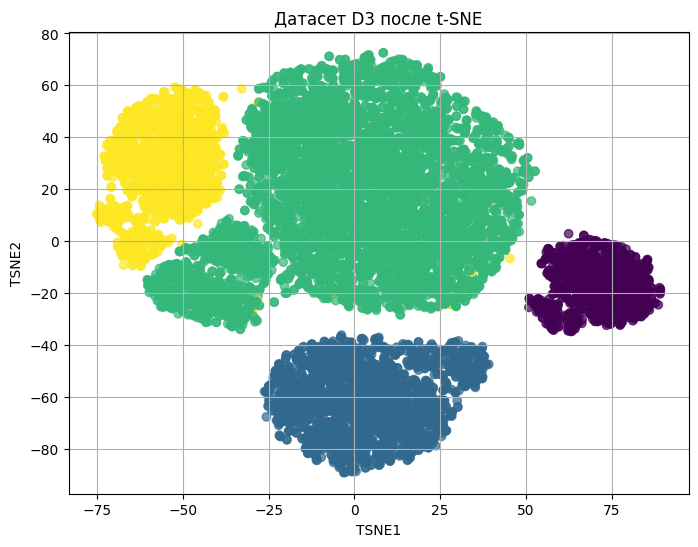

In [ ]:
category_map = {'Poor':1, 'Fair':2, 'Good':3, 'Excellent':4}
category_colors = df['Sleep_Quality'].map(category_map)

plt.figure(figsize=(8, 6))
plt.scatter(D2_df['PC1'], D2_df['PC2'], c=category_colors, alpha=0.7)
plt.title('Датасет D2 после PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(D3_df['TSNE1'], D3_df['TSNE2'], c=category_colors, alpha=0.7)
plt.title('Датасет D3 после t-SNE')
plt.xlabel('TSNE1')
plt.ylabel('TSNE2')
plt.grid(True)
plt.show()

In [ ]:
def evaluate_clustering(data, labels, dataset_name, method_name):
    labels = np.array(labels)

    # Для DBSCAN шумовые точки имеют метку -1.
    # Для корректного расчёта метрик исключим шум, если он есть.
    mask = labels != -1
    labels_without_noise = labels[mask]
    data_without_noise = data[mask]

    unique_labels = np.unique(labels_without_noise)

    if len(unique_labels) < 2:
        return {
            'Датасет': dataset_name,
            'Метод': method_name,
            'Количество кластеров': len(unique_labels),
            'Silhouette': np.nan,
            'Calinski-Harabasz': np.nan,
            'Davies-Bouldin': np.nan
        }

    return {
        'Датасет': dataset_name,
        'Метод': method_name,
        'Количество кластеров': len(unique_labels),
        'Silhouette': silhouette_score(data_without_noise, labels_without_noise),
        'Calinski-Harabasz': calinski_harabasz_score(data_without_noise, labels_without_noise),
        'Davies-Bouldin': davies_bouldin_score(data_without_noise, labels_without_noise)
    }

In [ ]:
datasets = {
    'D1': D1,
    'D2': D2,
    'D3': D3
}

all_results = []
cluster_labels = {}

for dataset_name, data in datasets.items():

    # KMeans
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    labels_kmeans = kmeans.fit_predict(data)
    all_results.append(evaluate_clustering(data, labels_kmeans, dataset_name, 'KMeans'))
    cluster_labels[(dataset_name, 'KMeans')] = labels_kmeans

    # Agglomerative Clustering
    agglomerative = AgglomerativeClustering(n_clusters=3)
    labels_agglomerative = agglomerative.fit_predict(data)
    all_results.append(evaluate_clustering(data, labels_agglomerative, dataset_name, 'Agglomerative'))
    cluster_labels[(dataset_name, 'Agglomerative')] = labels_agglomerative

    # DBSCAN
    if dataset_name == 'D1':
        dbscan = DBSCAN(eps=1.5, min_samples=5)
    else:
        dbscan = DBSCAN(eps=3.0, min_samples=5)

    labels_dbscan = dbscan.fit_predict(data)
    all_results.append(evaluate_clustering(data, labels_dbscan, dataset_name, 'DBSCAN'))
    cluster_labels[(dataset_name, 'DBSCAN')] = labels_dbscan

results_df = pd.DataFrame(all_results)

print("Результаты кластеризации:")
print(results_df)

Результаты кластеризации:
  Датасет          Метод  Количество кластеров  Silhouette  Calinski-Harabasz  \
0      D1         KMeans                     3    0.106301        1285.659269   
1      D1  Agglomerative                     3    0.068964        1016.179502   
2      D1         DBSCAN                     2    0.464191          12.851460   
3      D2         KMeans                     3    0.432989        8802.132676   
4      D2  Agglomerative                     3    0.428529        8579.389773   
5      D2         DBSCAN                     1         NaN                NaN   
6      D3         KMeans                     3    0.414406        9031.070312   
7      D3  Agglomerative                     3    0.381011        7223.002441   
8      D3         DBSCAN                     5    0.261379        5539.879395   

   Davies-Bouldin  
0        2.469519  
1        3.080005  
2        0.768001  
3        0.792130  
4        0.801754  
5             NaN  
6        0.847543  
7  

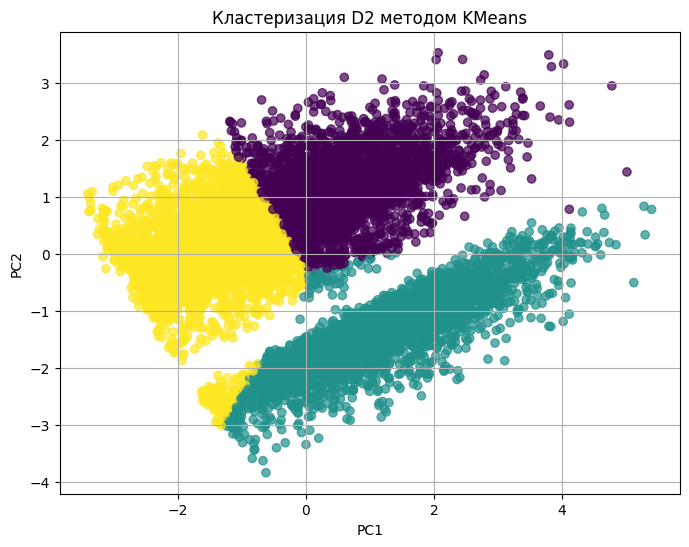

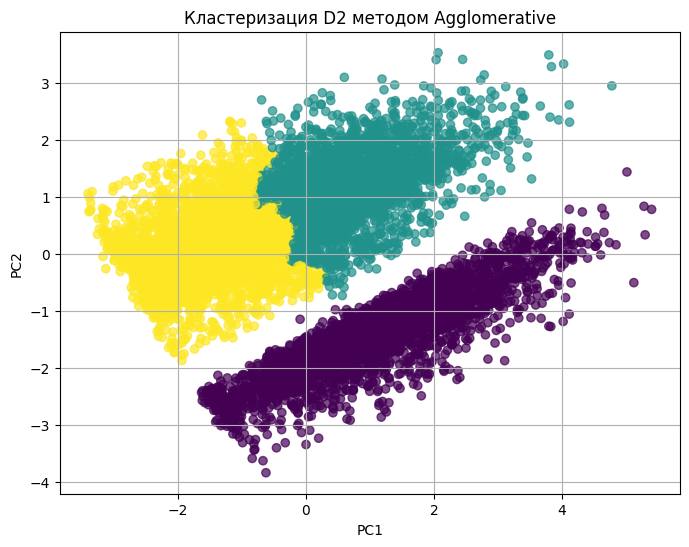

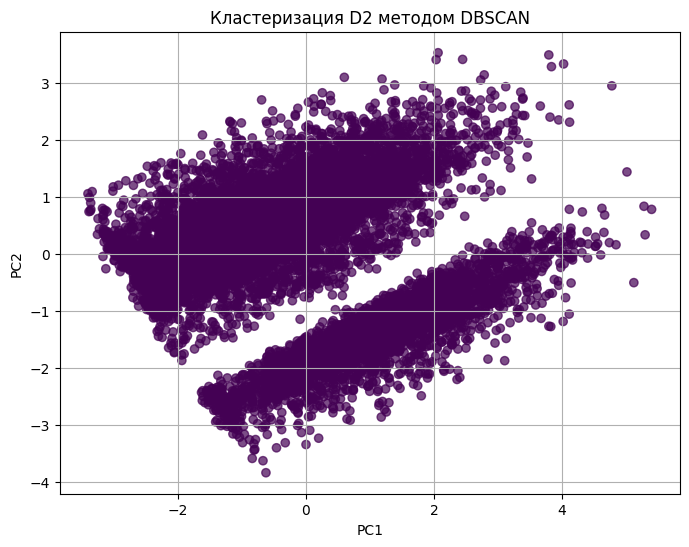

In [ ]:
for method in ['KMeans', 'Agglomerative', 'DBSCAN']:
    labels = cluster_labels[('D2', method)]

    plt.figure(figsize=(8, 6))
    plt.scatter(D2_df['PC1'], D2_df['PC2'], c=labels, alpha=0.7)
    plt.title(f'Кластеризация D2 методом {method}')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.grid(True)
    plt.show()

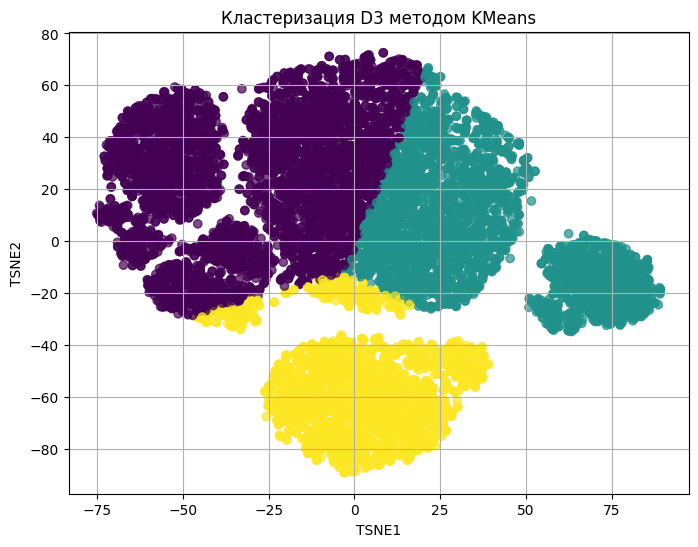

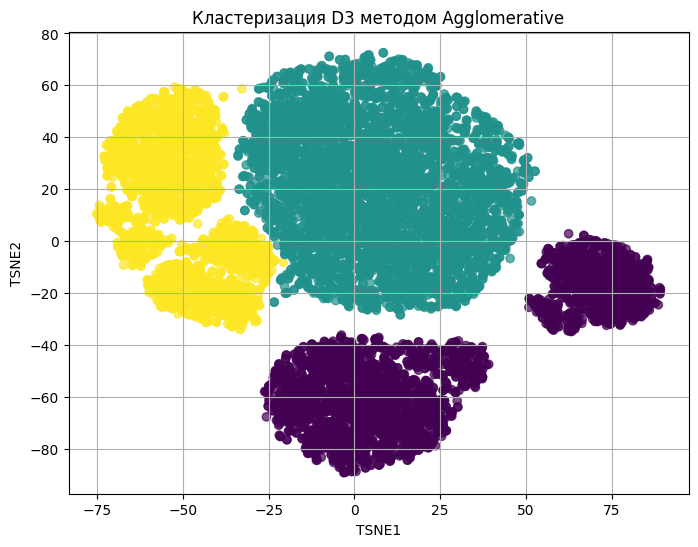

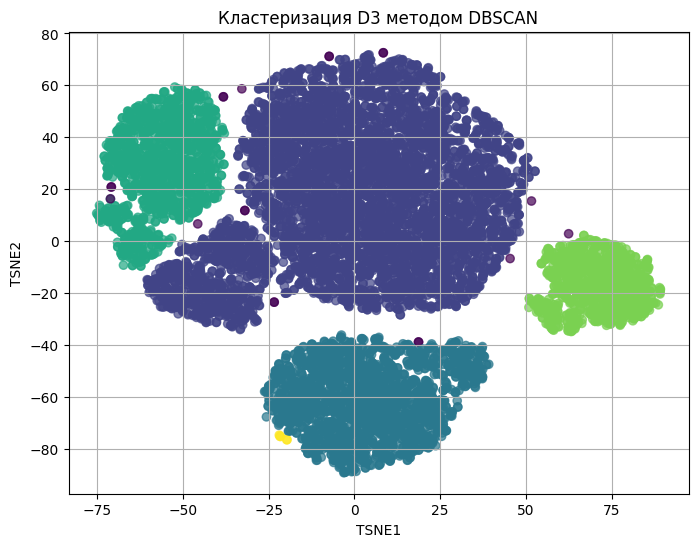

In [ ]:
for method in ['KMeans', 'Agglomerative', 'DBSCAN']:
    labels = cluster_labels[('D3', method)]

    plt.figure(figsize=(8, 6))
    plt.scatter(D3_df['TSNE1'], D3_df['TSNE2'], c=labels, alpha=0.7)
    plt.title(f'Кластеризация D3 методом {method}')
    plt.xlabel('TSNE1')
    plt.ylabel('TSNE2')
    plt.grid(True)
    plt.show()

In [ ]:
results_df_sorted = results_df.sort_values(
    by=['Датасет', 'Silhouette'],
    ascending=[True, False]
)

print("Итоговое сравнение методов кластеризации:")
print(results_df_sorted)

Итоговое сравнение методов кластеризации:
  Датасет          Метод  Количество кластеров  Silhouette  Calinski-Harabasz  \
2      D1         DBSCAN                     2    0.464191          12.851460   
0      D1         KMeans                     3    0.106301        1285.659269   
1      D1  Agglomerative                     3    0.068964        1016.179502   
3      D2         KMeans                     3    0.432989        8802.132676   
4      D2  Agglomerative                     3    0.428529        8579.389773   
5      D2         DBSCAN                     1         NaN                NaN   
6      D3         KMeans                     3    0.414406        9031.070312   
7      D3  Agglomerative                     3    0.381011        7223.002441   
8      D3         DBSCAN                     5    0.261379        5539.879395   

   Davies-Bouldin  
2        0.768001  
0        2.469519  
1        3.080005  
3        0.792130  
4        0.801754  
5             NaN  
6      

In [ ]:
best_methods = (
    results_df
    .dropna()
    .sort_values(by='Silhouette', ascending=False)
    .groupby('Датасет')
    .head(1)
)

print("Лучший метод кластеризации для каждого датасета:")
print(best_methods)

Лучший метод кластеризации для каждого датасета:
  Датасет   Метод  Количество кластеров  Silhouette  Calinski-Harabasz  \
2      D1  DBSCAN                     2    0.464191          12.851460   
3      D2  KMeans                     3    0.432989        8802.132676   
6      D3  KMeans                     3    0.414406        9031.070312   

   Davies-Bouldin  
2        0.768001  
3        0.792130  
6        0.847543  
